# Notebook 05b: Reflection reach and the possible futures of Idea 5

Notebook 05a runs the single decisive probe on the frozen `d0acc262` checkpoint and emits one verdict.
This notebook does the two things 05a cannot:

1. **Possible-futures simulator.** Before the real numbers land, it is worth knowing exactly what each
   outcome would look like and what claim it would license. We deterministically synthesize the four
   canonical futures of the signed-laterality probe (clean-flip positive, decodable-but-non-flipping,
   informative null, artifact), score each against the SAME pre-registered margins 05a uses, and draw
   their expected-shape panels. This is a pre-registration aid, not a result.

2. **External multi-view reach scaffold.** The clinical claim on gavd5-draft (n=18 source videos) is
   internal-validity only. The reflection-equivariance idea has a NON-clinical reach test on public
   multi-view pose cohorts (CASIA-B, OU-MVLP-Pose): does the signed axis stay stable across camera
   views, and does a genuine left/right camera swap flip it. We lay down a runnable, honestly-stubbed
   loader interface for that arm and state precisely why it is reach-tier and non-clinical.

Every margin here is copied verbatim from the proposal: beat the untrained floor by at least 0.05
R-squared, reach at least 80 percent of the raw-coordinate-null R-squared, decoded sign correct on at
least 75 percent of held-out sources, and a mirror slope inside the band [-1.25, -0.8] to count as a
flip. See `notes/ideas-claude/_shared_facts.md` for the single source of truth. Folder labels are
dataset annotations, not diagnoses; all gavd5-draft readouts are transductive.

## Reader's guide: how to understand these simulated futures

This notebook assumes no machine-learning background. A **future** here means one possible pattern
of scores that notebook 05a could have produced. The four patterns in this notebook are simulated:
they are deliberately invented examples used to rehearse the decision rules. **Simulated** or
**synthetic** data are made by code; **empirical** data are measurements collected from real videos
or people. A synthetic example can show that code and decision logic work, but it cannot show that a
trained model works on the real world.

### The prediction words

A **signed laterality axis** is one number whose positive and negative directions mean opposite
left-versus-right movement differences. A **linear probe**, **readout**, or **decoder** is a simple
weighted sum fitted to turn model features into that target number. **Decodable** means this simple
rule can recover the number. `R²`, or R-squared, compares its errors with always predicting the held-out
average: 1 is perfect, 0 is no better than the average, and a negative value is worse than repeatedly
predicting the average. Negative R-squared does not mean movement in a negative direction.

A **gate** is a pass-or-fail requirement fixed before seeing the result. Notebook 05a has three primary
gates: Lane A must beat the untrained model's floor, reach enough of the raw-coordinate ceiling, and
get the positive-versus-negative direction right across enough held-out source videos. All three must
pass. A **floor** is the performance available without representation learning; a **ceiling** is a
strong coordinate-level reference showing that the target is recoverable from the supplied input.

### The mirror words

**Decoded-original** is the readout's signed prediction for an ordinary pose. **Decoded-mirrored** is
the prediction from the same readout after the horizontal coordinate is reversed and left/right joint
names are swapped. If decoded-original is `+2`, the desired decoded-mirrored value is about `-2`. On a
plot of mirrored against original predictions, this gives a slope of `-1`. Equal size with opposite
sign is called **antisymmetry**. **Reflection equivariance** is the broader idea that the model output
changes according to this known rule when the input is reflected. The **mirror test** checks that rule;
it asks how the information is organized, not merely whether the target can be predicted.

### The control and limitation words

Lane D is a **nuisance control**: it removes explicit left/right identity and keeps side-agnostic
summaries such as overall averages and standard deviations. A **nuisance** is an unwanted shortcut,
such as movement magnitude, video style, or pose-detector behavior. A **clean nuisance control** means
Lane D stays near zero, as it should if the claimed signal really needs left/right identity. This
rules out one planned shortcut; it does not prove that every possible shortcut is absent.

The gavd5-draft result is **transductive** because the encoder learned from the same corpus before its frozen
features were divided into probe-training and probe-test videos. The probe split is still
source-video-disjoint, but the encoder has not been tested on an entirely unseen collection.
**High-dimensional** means the probe has many feature columns compared with the small number of
independent source videos; accidental patterns and unstable weights are therefore a concern.

For the external reach arm, **participant-disjoint** means no person appears in both fitting and test
sets. **External validity** means that a finding continues to hold for genuinely new people, cameras,
or datasets rather than only the collection used to develop it. A high correlation on synthetic
multi-view clips validates the software path only; it provides no external validity because the stable
pattern was planted by construction.

## 0. The pre-registered margins (frozen, copied from the proposal)

These four constants are the entire decision rule. A threshold is called a **gate** because it is a
pass-or-fail checkpoint. Nothing downstream may change these gates; the simulator and the real
notebook both import the same numbers so a future cannot be scored on a moved goalpost.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd

RANDOM_SEED = 42


def idea5_dir():
    '''Resolve the 05 proposal folder robustly regardless of the kernel cwd.'''
    for base in [Path.cwd(), *Path.cwd().parents]:
        cand = base / "notes" / "ideas-claude" / "05-signed-laterality-decodability"
        if cand.exists():
            return cand
        cand = base / "05-signed-laterality-decodability"
        if cand.exists():
            return cand
    return Path.cwd()


IDEA5_DIR = idea5_dir()
print(f"IDEA5_DIR: {IDEA5_DIR}")

# ---- pre-registered margins (proposal "The decisive experiment") ----
FLOOR_MARGIN = 0.05          # Lane A must beat Lane C (untrained floor) by >= this R2.
NULL_FRACTION = 0.80         # Lane A must reach >= this fraction of Lane B (raw-null) R2.
SIGN_CONSISTENCY = 0.75      # decoded sign correct on >= this fraction of held-out sources.
MIRROR_BAND = (-1.25, -0.8)  # mirror slope inside this band counts as "flips".

print("Pre-registered decision rule:")
print(f"  beat untrained floor by         >= {FLOOR_MARGIN} R2")
print(f"  reach fraction of raw null      >= {NULL_FRACTION}")
print(f"  decoded-sign correct on sources >= {SIGN_CONSISTENCY}")
print(f"  mirror slope band for 'flips'    = {MIRROR_BAND}")

IDEA5_DIR: /Users/pmui/dev/alexpose/experiments/sjepa/gavd5-draft/notes/ideas-claude/05-signed-laterality-decodability
Pre-registered decision rule:
  beat untrained floor by         >= 0.05 R2
  reach fraction of raw null      >= 0.8
  decoded-sign correct on sources >= 0.75
  mirror slope band for 'flips'    = (-1.25, -0.8)


## 1. One scoring function, shared by every future

`score_future` takes the four lane R-squared values, the fraction of held-out sources for which the
probe predicts the correct positive-or-negative direction, and the mirror slope. It returns the exact
verdict language the proposal pre-registers.
The primary verdict is a positive ("signed axis present above raw") ONLY if all three primary checks
pass together; otherwise it is an informative null. The mirror verdict is reported separately as the
secondary mechanism endpoint. The nuisance control (Lane D) must not recover a signed axis.

In [2]:
def score_future(a_r2, b_r2, c_r2, d_r2, sign_frac, mirror_slope):
    beats_floor = (a_r2 - c_r2) >= FLOOR_MARGIN
    reaches_null = a_r2 >= NULL_FRACTION * max(b_r2, 1e-9)
    sign_ok = sign_frac >= SIGN_CONSISTENCY
    primary_positive = bool(beats_floor and reaches_null and sign_ok)
    flips = bool(MIRROR_BAND[0] <= mirror_slope <= MIRROR_BAND[1])
    # Lane D must stay near zero (side-agnostic by construction).
    d_control_ok = bool(abs(d_r2) < 0.05 or d_r2 < 0.5 * max(b_r2, 1e-9))
    if primary_positive:
        primary = "SIGNED AXIS PRESENT ABOVE RAW"
    else:
        primary = "INFORMATIVE NULL (signed axis not linearly present above raw)"
    if flips:
        mirror = "FLIPS (encoding is antisymmetric under the mirror)"
    else:
        mirror = "DOES NOT FLIP (encoding is non-antisymmetric)"
    return {
        "beats_floor": beats_floor, "reaches_null": reaches_null, "sign_ok": sign_ok,
        "primary_positive": primary_positive, "flips": flips, "d_control_ok": d_control_ok,
        "primary_verdict": primary, "mirror_verdict": mirror,
    }


# sanity: the worked example from the proposal (A=0.42, B=0.50, C=0.05, sign 0.75) is a primary pass
_demo = score_future(0.42, 0.50, 0.05, -0.30, 0.75, -1.0)
assert _demo["primary_positive"] and _demo["flips"], _demo
print("scoring self-check OK (proposal worked example scores as a primary pass, mirror flips).")

scoring self-check OK (proposal worked example scores as a primary pass, mirror flips).


## 2. The four canonical possible futures

Each future is a named, plausible state of the world with the lane numbers it would produce. They are
illustrative expected shapes, not measurements. The point is that the decision rule is total: every
future maps to an unambiguous, pre-registered claim.

- **F1 clean-flip positive.** The learned encoder carries the signed axis competitively with raw
  coordinates and the mirror cleanly negates it. This is the strong result: reflection-equivariance is
  learned, and the lateralized-vs-symmetric separation (stroke / hemiplegic-CP / early-PD vs myopathy)
  has a mechanism-faithful substrate.
- **F2 decodable-but-non-flipping.** The signed axis is linearly present above raw, but the mirror does
  not cleanly flip it. The encoding is informative yet non-antisymmetric: it decodes side without
  respecting the reflection symmetry. Licenses the decodability claim, withholds the equivariance claim.
- **F3 informative null.** The learned features do not clear the floor-plus-null bar. Raw coordinates
  decode the signed axis but the frozen S-JEPA tokens do not add it linearly. This overturns the
  hypothesis that the checkpoint has organized a laterality axis, and it is a publishable negative for a
  representation audit.
- **F4 artifact.** Lane A looks strong BUT the mean/std-pooled nuisance control (Lane D) also "recovers"
  the axis, which is impossible for a genuinely signed quantity. The apparent signal is a magnitude or
  acquisition artifact and the signed claim is withdrawn.

In [3]:
FUTURES = [
    {"key": "F1_clean_flip_positive",
     "title": "F1 clean-flip positive",
     "a_r2": 0.44, "b_r2": 0.50, "c_r2": 0.06, "d_r2": -0.02, "sign_frac": 0.83, "mirror_slope": -1.02},
    {"key": "F2_decodable_non_flip",
     "title": "F2 decodable but non-flipping",
     "a_r2": 0.41, "b_r2": 0.50, "c_r2": 0.05, "d_r2": 0.01, "sign_frac": 0.80, "mirror_slope": -0.25},
    {"key": "F3_informative_null",
     "title": "F3 informative null",
     "a_r2": 0.12, "b_r2": 0.48, "c_r2": 0.08, "d_r2": 0.00, "sign_frac": 0.55, "mirror_slope": -0.6},
    {"key": "F4_artifact",
     "title": "F4 artifact (nuisance control fires)",
     "a_r2": 0.47, "b_r2": 0.50, "c_r2": 0.06, "d_r2": 0.46, "sign_frac": 0.82, "mirror_slope": -0.9},
]

rows = []
for f in FUTURES:
    v = score_future(f["a_r2"], f["b_r2"], f["c_r2"], f["d_r2"], f["sign_frac"], f["mirror_slope"])
    rows.append({
        "future": f["title"], "A_r2": f["a_r2"], "B_r2": f["b_r2"], "C_r2": f["c_r2"], "D_r2": f["d_r2"],
        "sign_frac": f["sign_frac"], "mirror_slope": f["mirror_slope"],
        "primary": v["primary_verdict"], "mirror": v["mirror_verdict"],
        "D_control_ok": v["d_control_ok"],
    })
futures_table = pd.DataFrame(rows)
pd.set_option("display.max_colwidth", 60)
print(futures_table.to_string(index=False))

                              future  A_r2  B_r2  C_r2  D_r2  sign_frac  mirror_slope                                                       primary                                             mirror  D_control_ok
              F1 clean-flip positive  0.44  0.50  0.06 -0.02       0.83         -1.02                                 SIGNED AXIS PRESENT ABOVE RAW FLIPS (encoding is antisymmetric under the mirror)          True
       F2 decodable but non-flipping  0.41  0.50  0.05  0.01       0.80         -0.25                                 SIGNED AXIS PRESENT ABOVE RAW      DOES NOT FLIP (encoding is non-antisymmetric)          True
                 F3 informative null  0.12  0.48  0.08  0.00       0.55         -0.60 INFORMATIVE NULL (signed axis not linearly present above raw)      DOES NOT FLIP (encoding is non-antisymmetric)          True
F4 artifact (nuisance control fires)  0.47  0.50  0.06  0.46       0.82         -0.90                                 SIGNED AXIS PRESENT ABOVE RAW 

## 3. The decision table: future -> licensed claim

This is the single artifact a reviewer should read first. It states, for every future, exactly which
claim is licensed and which is withheld. Note F4: when the nuisance control fires, the primary "signed"
claim is withdrawn regardless of how strong Lane A looked, because a mean/std pooling is side-agnostic
by construction and cannot carry a genuinely signed quantity.

In [4]:
CLAIMS = {
    "F1 clean-flip positive": (
        "LICENSED: the frozen encoder linearly carries the signed laterality axis competitively with "
        "raw coordinates AND the encoding is antisymmetric under the anatomical mirror. Supports the "
        "reflection-equivariant symmetry-axis reading (Idea 9 substrate confirmed)."),
    "F2 decodable but non-flipping": (
        "LICENSED: signed axis is linearly present above raw coordinates. WITHHELD: reflection "
        "equivariance; the encoding decodes side without respecting the mirror symmetry."),
    "F3 informative null": (
        "LICENSED (negative): the frozen S-JEPA tokens do NOT add the signed axis above raw "
        "coordinates. Overturns the hypothesis that the checkpoint organized a laterality axis; a "
        "clean publishable negative for the representation audit."),
    "F4 artifact (nuisance control fires)": (
        "WITHHELD: the signed claim is withdrawn. The side-agnostic mean/std control recovered the "
        "'axis', so Lane A reflects a magnitude/acquisition artifact, not a signed quantity."),
}
decision = futures_table[["future", "primary", "mirror", "D_control_ok"]].copy()
decision["licensed_claim"] = decision["future"].map(CLAIMS)
for _, r in decision.iterrows():
    print(f"### {r['future']}")
    print(f"  primary : {r['primary']}")
    print(f"  mirror  : {r['mirror']}")
    print(f"  D control ok: {r['D_control_ok']}")
    print(f"  claim   : {r['licensed_claim']}")
    print()

### F1 clean-flip positive
  primary : SIGNED AXIS PRESENT ABOVE RAW
  mirror  : FLIPS (encoding is antisymmetric under the mirror)
  D control ok: True
  claim   : LICENSED: the frozen encoder linearly carries the signed laterality axis competitively with raw coordinates AND the encoding is antisymmetric under the anatomical mirror. Supports the reflection-equivariant symmetry-axis reading (Idea 9 substrate confirmed).

### F2 decodable but non-flipping
  primary : SIGNED AXIS PRESENT ABOVE RAW
  mirror  : DOES NOT FLIP (encoding is non-antisymmetric)
  D control ok: True
  claim   : LICENSED: signed axis is linearly present above raw coordinates. WITHHELD: reflection equivariance; the encoding decodes side without respecting the mirror symmetry.

### F3 informative null
  primary : INFORMATIVE NULL (signed axis not linearly present above raw)
  mirror  : DOES NOT FLIP (encoding is non-antisymmetric)
  D control ok: True
  claim   : LICENSED (negative): the frozen S-JEPA tokens do NOT

## 4. Expected-shape panels for each future

For each future we synthesize a point cloud that reproduces its lane R-squared and mirror slope, so the
reader sees the SHAPE each outcome makes on the two decisive plots (decodability scatter and mirror
scatter). These are simulated to the target statistics; they are not data. The panels mirror the two
SVG mockups in the proposal's `images/` folder.

saved /Users/pmui/dev/alexpose/experiments/sjepa/gavd5-draft/notes/ideas-claude/05-signed-laterality-decodability/images/idea5_possible_futures.png


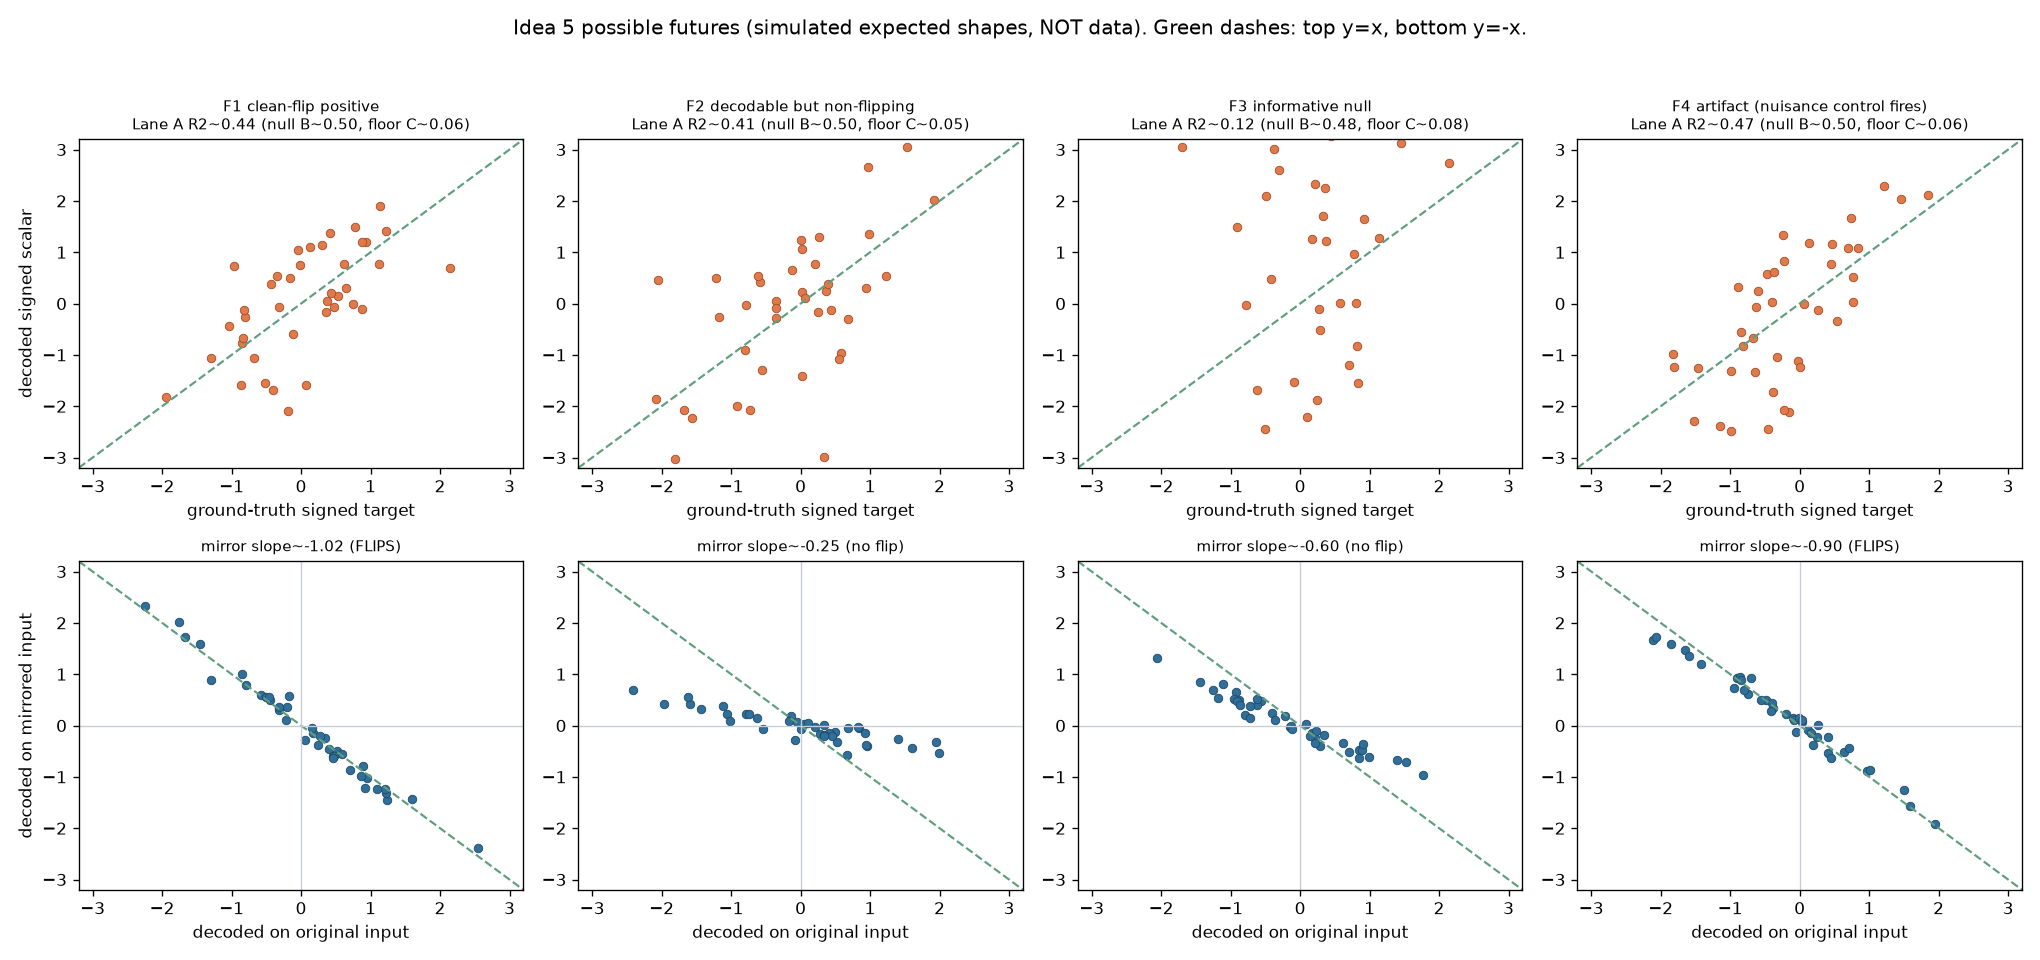

In [5]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image as IPythonImage, display


def simulate_scatter(r2, n=40, seed=0):
    '''Return (y_true, y_pred) with approximately the requested held-out R2.'''
    rng = np.random.default_rng(seed)
    y = rng.normal(0, 1, n)
    if r2 <= 0:
        pred = rng.normal(0, 1, n)  # no relationship; R2 near 0 or negative
    else:
        noise_var = (1 - r2) / max(r2, 1e-6)
        pred = y + rng.normal(0, np.sqrt(noise_var), n)
    return y, pred


def simulate_mirror(slope, n=40, seed=0):
    rng = np.random.default_rng(seed)
    orig = rng.normal(0, 1, n)
    mir = slope * orig + rng.normal(0, 0.12, n)
    return orig, mir


fig, axes = plt.subplots(2, 4, figsize=(17, 8))
for col, f in enumerate(FUTURES):
    seed = RANDOM_SEED + col
    # top row: decodability (Lane A)
    yt, yp = simulate_scatter(f["a_r2"], seed=seed)
    ax = axes[0, col]
    ax.scatter(yt, yp, s=26, c="#e07a4b", edgecolors="#a44c26", linewidths=0.5)
    lim = 3.2
    ax.plot([-lim, lim], [-lim, lim], "--", color="#5f9e7e", linewidth=1.3)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
    ax.set_title(f"{f['title']}\nLane A R2~{f['a_r2']:.2f} (null B~{f['b_r2']:.2f}, floor C~{f['c_r2']:.2f})", fontsize=9)
    if col == 0:
        ax.set_ylabel("decoded signed scalar")
    ax.set_xlabel("ground-truth signed target")
    # bottom row: mirror
    orig, mir = simulate_mirror(f["mirror_slope"], seed=seed + 100)
    ax2 = axes[1, col]
    ax2.scatter(orig, mir, s=26, c="#2f6f99", edgecolors="#1f4a68", linewidths=0.5)
    mlim = 3.2
    ax2.plot([-mlim, mlim], [mlim, -mlim], "--", color="#5f9e7e", linewidth=1.3)
    ax2.axhline(0, color="#c4cdd8", lw=0.8); ax2.axvline(0, color="#c4cdd8", lw=0.8)
    ax2.set_xlim(-mlim, mlim); ax2.set_ylim(-mlim, mlim)
    flips = "FLIPS" if MIRROR_BAND[0] <= f["mirror_slope"] <= MIRROR_BAND[1] else "no flip"
    ax2.set_title(f"mirror slope~{f['mirror_slope']:+.2f} ({flips})", fontsize=9)
    if col == 0:
        ax2.set_ylabel("decoded on mirrored input")
    ax2.set_xlabel("decoded on original input")

fig.suptitle("Idea 5 possible futures (simulated expected shapes, NOT data). Green dashes: top y=x, bottom y=-x.", fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.96])
OUT = IDEA5_DIR / "images"
saved_figure = None
try:
    OUT.mkdir(parents=True, exist_ok=True)
    out_path = OUT / "idea5_possible_futures.png"
    fig.savefig(out_path, dpi=120)
    saved_figure = out_path
    print(f"saved {out_path}")
except Exception as exc:
    print(f"(figure not saved to images/: {exc})")
if saved_figure is not None:
    # Display the exact PNG that was written, even with the non-interactive Agg backend.
    display(IPythonImage(filename=str(saved_figure)))
else:
    # Preserve inline visibility if the output directory is not writable.
    display(fig)
plt.close(fig)

## 5. External multi-view reach arm (non-clinical scaffold)

The clinical claim on gavd5-draft is internal-validity only: n=18 canonical source videos, transductive
encoder, monocular capture. A simultaneously clinical + skeleton + participant-disjoint public cohort
does not exist, so there is NO honest skeleton-level clinical transfer test. What DOES exist is a
non-clinical reach test for the reflection-equivariance property itself, on public multi-view pose
cohorts:

- **CASIA-B** (Yu, Tan, Tan 2006): 124 subjects, 11 camera views (0 to 180 degrees). Non-clinical gait.
- **OU-MVLP-Pose** (Takemura et al. 2018): ~10,000 subjects, multiple views, pose keypoints released.

The reach question is symmetry-specific and view-specific, not clinical:

1. **View stability.** Is the signed axis decoded from one view consistent with the same subject decoded
   from a nearby view (small change), i.e. is it a property of the gait rather than the camera?
2. **Genuine mirror.** A true left-versus-right camera swap (a real physical reflection, not a synthetic
   x-negation) should flip the signed axis. CASIA-B's symmetric view angles around 90 degrees give a
   real-world analogue of the anatomical mirror.

This cell defines the loader interface and the two metrics, then runs them on a small synthetic
multi-view fixture so the scaffold is exercised. Wiring real downloads is deliberately left as a marked
TODO: these are large licensed datasets and this pass does not fetch them.

In [6]:
from dataclasses import dataclass, field


@dataclass
class MultiViewClip:
    subject_id: str
    view_deg: float          # camera azimuth in degrees
    coords: np.ndarray       # [T, 33, 3] normalized pose
    cohort: str = "synthetic"


def load_casia_b(root=None):
    '''TODO(real): parse CASIA-B pose export at `root` into MultiViewClip list.
    Not wired in this pass (large licensed dataset). Returns [] so the scaffold degrades cleanly.'''
    if root is None:
        return []
    raise NotImplementedError("Real CASIA-B loading is a marked TODO; provide a parser at call site.")


def load_ou_mvlp_pose(root=None):
    '''TODO(real): parse OU-MVLP-Pose keypoints at `root`. Not wired in this pass.'''
    if root is None:
        return []
    raise NotImplementedError("Real OU-MVLP-Pose loading is a marked TODO.")


def synthetic_multiview_fixture(n_subjects=6, views=(54.0, 90.0, 126.0), frames=40, seed=RANDOM_SEED):
    '''A tiny multi-view fixture: each subject has a fixed signed lean visible from every view; the
    view rotates the pose in the x-z plane so the signed x-excursion is genuinely view-dependent.'''
    rng = np.random.default_rng(seed)
    clips = []
    LEFT_RIGHT = [(11, 12), (23, 24), (25, 26), (27, 28), (29, 30), (31, 32)]
    for s in range(n_subjects):
        lean = 1.0 if s % 2 == 0 else -1.0
        phase = np.linspace(0, 4 * np.pi, frames, endpoint=False)
        base = np.zeros((frames, 33, 3), dtype=np.float32)
        for j in range(33):
            base[:, j, :] = rng.normal(0, 0.04, 3)[None, :] + 0.03 * np.sin(phase + j)[:, None]
        for li, ri in LEFT_RIGHT:
            base[:, li, 0] += 0.05 * lean * np.sin(phase)
            base[:, ri, 0] -= 0.05 * lean * np.sin(phase)
        for v in views:
            theta = np.deg2rad(v - 90.0)  # 90 deg is the frontal reference
            rot = np.array([[np.cos(theta), 0, np.sin(theta)], [0, 1, 0], [-np.sin(theta), 0, np.cos(theta)]])
            coords = base @ rot.T
            clips.append(MultiViewClip(subject_id=f"subj{s:02d}", view_deg=float(v), coords=coords.astype(np.float32)))
    return clips


LEFT_RIGHT_PAIRS = [(11, 12), (23, 24), (25, 26), (27, 28), (29, 30), (31, 32)]


def signed_axis(coords):
    total = 0.0
    for li, ri in LEFT_RIGHT_PAIRS:
        total += coords[:, li, :].std(axis=0).sum() - coords[:, ri, :].std(axis=0).sum()
    return float(total)


clips = synthetic_multiview_fixture()
print(f"external reach scaffold exercised on {len(clips)} synthetic multi-view clips "
      f"({len({c.subject_id for c in clips})} subjects x {len({c.view_deg for c in clips})} views).")

# Metric 1: view stability = corr of the per-subject signed axis across two nearby views.
df = pd.DataFrame([{"subject": c.subject_id, "view": c.view_deg, "axis": signed_axis(c.coords)} for c in clips])
wide = df.pivot(index="subject", columns="view", values="axis")
views_sorted = sorted(df["view"].unique())
if len(views_sorted) >= 2:
    v_lo, v_hi = views_sorted[0], views_sorted[-1]
    stability = float(np.corrcoef(wide[v_lo], wide[v_hi])[0, 1])
    print(f"view-stability corr(axis@{v_lo:.0f}deg, axis@{v_hi:.0f}deg) = {stability:+.3f}  (expect strong positive)")
print("\nNOTE: synthetic fixture only. Real CASIA-B / OU-MVLP-Pose loading is a marked TODO. "
      "This arm is NON-CLINICAL and reach-tier; it tests the reflection property, not any diagnosis.")

external reach scaffold exercised on 18 synthetic multi-view clips (6 subjects x 3 views).
view-stability corr(axis@54deg, axis@126deg) = +1.000  (expect strong positive)

NOTE: synthetic fixture only. Real CASIA-B / OU-MVLP-Pose loading is a marked TODO. This arm is NON-CLINICAL and reach-tier; it tests the reflection property, not any diagnosis.


## 6. Persist the futures + decision bundle

We write the futures table and the decision map to JSON next to the notebook so the methodology
document and README can cite the exact simulated shapes, and so a reader can diff the eventual real
`idea5_signed_laterality_result.json` (from 05a) against the four canonical futures here.

In [7]:
import json
bundle = {
    "notebook": "nb_05b_reflection_reach_and_futures",
    "margins": {"floor_margin": FLOOR_MARGIN, "null_fraction": NULL_FRACTION,
                "sign_consistency": SIGN_CONSISTENCY, "mirror_band": list(MIRROR_BAND)},
    "futures": rows,
    "decision": {r["future"]: {"primary": r["primary"], "mirror": r["mirror"],
                               "D_control_ok": bool(r["D_control_ok"]), "claim": CLAIMS[r["future"]]}
                 for r in rows},
    "external_reach": {
        "cohorts": ["CASIA-B (Yu 2006)", "OU-MVLP-Pose (Takemura 2018)"],
        "status": "scaffold only; real loaders are marked TODO",
        "tier": "non-clinical reach; tests reflection stability + genuine-mirror flip, not diagnosis",
    },
    "notes": "Simulated expected shapes, NOT data. gavd5-draft clinical claim is internal-validity only.",
}
out = IDEA5_DIR / "idea5_futures_bundle.json"
try:
    out.write_text(json.dumps(bundle, indent=2))
    print(f"wrote {out}")
except Exception as exc:
    print(f"(bundle not written: {exc})")
print(json.dumps({"margins": bundle["margins"], "n_futures": len(rows)}, indent=2))

wrote /Users/pmui/dev/alexpose/experiments/sjepa/gavd5-draft/notes/ideas-claude/05-signed-laterality-decodability/idea5_futures_bundle.json
{
  "margins": {
    "floor_margin": 0.05,
    "null_fraction": 0.8,
    "sign_consistency": 0.75,
    "mirror_band": [
      -1.25,
      -0.8
    ]
  },
  "n_futures": 4
}


## 7. Discussion: how to reason from each possible future

This section is a tutorial for interpreting the simulator and synthetic reach output. It deliberately distinguishes a decision-rule test from a scientific measurement.


In [8]:
from IPython.display import Markdown, display

reach_value = f"{stability:+.3f}" if "stability" in globals() else "not computed"
discussion_markdown = f"""
### Step 1: identify what was actually run

This notebook ran two engineering exercises. First, it generated four **simulated** patterns representing the major ways the laterality probe could turn out. Second, it ran the external-reach interface on a deliberately constructed synthetic multi-view fixture. Neither exercise evaluated the frozen S-JEPA checkpoint on new empirical data. The correct starting point is therefore: **these outputs validate interpretation and plumbing, not the scientific hypothesis.**

### Step 2: understand the three primary checks

A gate is a pass-or-fail requirement fixed before the result is known. The three primary gates are:

1. **Beat the untrained floor:** Lane A must exceed Lane C by at least `0.05` R-squared. This asks whether learning helped beyond random, never-trained encoder features.
2. **Approach the raw-coordinate ceiling:** Lane A must reach at least `80%` of Lane B's R-squared. This asks whether the learned representation retained a substantial part of a target that is recoverable directly from coordinates.
3. **Preserve direction across sources:** Lane A must predict the correct positive-or-negative sign for at least `75%` of held-out source videos. This asks whether left-versus-right direction is dependable rather than changing unpredictably between videos.

All three must pass; one attractive score cannot compensate for another failed requirement. The mirror test is separate: it checks whether the same decoded quantity reverses under reflection. Decoded-original means the prediction from the ordinary pose. Decoded-mirrored means the prediction from the same readout after horizontal coordinates and left/right landmark identities are swapped. A `+2` original should become about `-2`, producing a slope near `-1`; the mirror gate accepts slopes in `[-1.25, -0.8]`. Lane D adds a nuisance-control safeguard. That control passes when Lane D's R-squared is within 0.05 of zero in either direction, or below half of Lane B's R-squared. In everyday terms, features that no longer identify left and right must predict poorly or stay far below the raw-coordinate signal. If they predict too well, the signed interpretation is withdrawn as an artifact warning.

### Step 3: interpret F1, the clean positive

F1 passes all three primary gates, keeps Lane D near zero, and produces a mirror slope inside the pre-agreed band. In its accuracy panel, points follow `y = x`: prediction and truth are equal. In its mirror panel, points follow `y = -x`: the mirror prediction has the same size and opposite sign. This opposite-sign rule is antisymmetry. F1 would license the narrow claim that the chosen frozen features expose the signed target to a simple linear readout and transform according to the tested mirror rule. It would still not establish diagnosis, cause and effect, or performance on unseen populations.

### Step 4: interpret F2, decodable but not equivariant

F2 passes all three prediction gates but its mirror slope is not near `-1`. In plain language, the readout can recover the signed number, yet mirroring the input does not reliably reverse that number. The features contain useful information but do not organize it according to the expected reflection rule. These are different properties: having an answer somewhere in the features is not the same as arranging the answer so it changes predictably when the input changes. F2 would support the linear-prediction claim but not the reflection-equivariance claim.

### Step 5: interpret F3, the informative null

F3 leaves the raw-coordinate lane strong but the learned lane weak. The target is therefore available in the input, while the tested frozen features do not make it accessible enough to the registered simple readout. If an R-squared is negative, remember that this specifically means its prediction errors are worse than always guessing the held-out average; it does not mean negative-direction movement. When direction consistency and mirror behavior also fail, the proposed signed internal axis was not found in the tested form. This is an **informative null** rather than an uninterpretable failure because the target, split, comparisons, gates, and meaning of failure were all set in advance. It rejects this narrow tested hypothesis; it does not prove that no nonlinear method or other model layer contains laterality.

### Step 6: interpret F4, the artifact warning

F4 is intentionally deceptive: Lane A and the mirror score look positive, but the side-agnostic Lane D also predicts the supposedly signed quantity. Lane D deliberately forgets which joints are left and right, keeping only pooled summaries such as global means and standard deviations. Its success therefore warns that overall movement size, source-video style, pose-estimation behavior, or another unwanted shortcut may explain the result. The control is **not clean** in F4, so passing the attractive primary numbers is insufficient and the signed interpretation must be withdrawn. A clean control would mean Lane D stays low as intended; even then, it would rule out only this planned shortcut, not every imaginable artifact.

### Step 7: read the expected-shape image

The top row visualizes prediction. The horizontal position is the true target and the vertical position is the decoded prediction. Points close to `y = x` indicate that prediction equals truth; a scattered cloud indicates weak prediction. The bottom row visualizes the mirror test. The horizontal position is decoded-original, and the vertical position is decoded-mirrored from the same readout. Points close to `y = -x` mean `+2` becomes `-2`, or `-3` becomes `+3`, as desired. A shallow, flat, or positive trend means the value does not reverse correctly. These panels are educational templates generated to resemble their assigned statistics. They are not uncertainty plots and contain no observed checkpoint samples.

### Step 8: interpret the synthetic multi-view correlation

The fixture produced a view-stability correlation of `{reach_value}` across `{len(clips)}` synthetic clips. Correlation measures whether two lists vary together; `+1` means they rise and fall together perfectly. Here that value is high because each made-up subject was deliberately given a stable signed pattern and then rotated by code into multiple views. The answer was planted in the fixture. The result confirms that the data container, rotation, grouping, table reshaping, and correlation code connect correctly. It cannot estimate performance on CASIA-B, OU-MVLP-Pose, or any clinical cohort. A synthetic test can reveal broken software plumbing; it cannot demonstrate **external validity**, meaning reliable performance on genuinely new real people, cameras, or datasets.

### Step 9: identify what a real reach experiment requires

A credible real run needs licensed data loading, a documented mapping from each dataset's joint names to the model's required 33 landmarks, camera-view pairs chosen in advance, rules for missing joints, and a genuine reflection definition. It also needs **participant-disjoint** fitting: every person must appear either on the fitting side or on the test side, never both. View stability and mirror flipping should be reported with uncertainty across independent people, not merely across many clips from the same people. Clinical language must remain out of scope because these public multi-view cohorts are non-clinical.

### Discussion conclusion

The notebook succeeds as a claim-discipline tool: each possible numeric pattern maps to a bounded statement, the nuisance control can veto a seductive artifact, and the external scaffold runs end to end. Its observed `+1.000` synthetic correlation is not a discovery. The scientific value here is the pre-committed interpretation framework and the explicit list of work still required before making an external reflection claim.
"""
display(Markdown(discussion_markdown))



### Step 1: identify what was actually run

This notebook ran two engineering exercises. First, it generated four **simulated** patterns representing the major ways the laterality probe could turn out. Second, it ran the external-reach interface on a deliberately constructed synthetic multi-view fixture. Neither exercise evaluated the frozen S-JEPA checkpoint on new empirical data. The correct starting point is therefore: **these outputs validate interpretation and plumbing, not the scientific hypothesis.**

### Step 2: understand the three primary checks

A gate is a pass-or-fail requirement fixed before the result is known. The three primary gates are:

1. **Beat the untrained floor:** Lane A must exceed Lane C by at least `0.05` R-squared. This asks whether learning helped beyond random, never-trained encoder features.
2. **Approach the raw-coordinate ceiling:** Lane A must reach at least `80%` of Lane B's R-squared. This asks whether the learned representation retained a substantial part of a target that is recoverable directly from coordinates.
3. **Preserve direction across sources:** Lane A must predict the correct positive-or-negative sign for at least `75%` of held-out source videos. This asks whether left-versus-right direction is dependable rather than changing unpredictably between videos.

All three must pass; one attractive score cannot compensate for another failed requirement. The mirror test is separate: it checks whether the same decoded quantity reverses under reflection. Decoded-original means the prediction from the ordinary pose. Decoded-mirrored means the prediction from the same readout after horizontal coordinates and left/right landmark identities are swapped. A `+2` original should become about `-2`, producing a slope near `-1`; the mirror gate accepts slopes in `[-1.25, -0.8]`. Lane D adds a nuisance-control safeguard. That control passes when Lane D's R-squared is within 0.05 of zero in either direction, or below half of Lane B's R-squared. In everyday terms, features that no longer identify left and right must predict poorly or stay far below the raw-coordinate signal. If they predict too well, the signed interpretation is withdrawn as an artifact warning.

### Step 3: interpret F1, the clean positive

F1 passes all three primary gates, keeps Lane D near zero, and produces a mirror slope inside the pre-agreed band. In its accuracy panel, points follow `y = x`: prediction and truth are equal. In its mirror panel, points follow `y = -x`: the mirror prediction has the same size and opposite sign. This opposite-sign rule is antisymmetry. F1 would license the narrow claim that the chosen frozen features expose the signed target to a simple linear readout and transform according to the tested mirror rule. It would still not establish diagnosis, cause and effect, or performance on unseen populations.

### Step 4: interpret F2, decodable but not equivariant

F2 passes all three prediction gates but its mirror slope is not near `-1`. In plain language, the readout can recover the signed number, yet mirroring the input does not reliably reverse that number. The features contain useful information but do not organize it according to the expected reflection rule. These are different properties: having an answer somewhere in the features is not the same as arranging the answer so it changes predictably when the input changes. F2 would support the linear-prediction claim but not the reflection-equivariance claim.

### Step 5: interpret F3, the informative null

F3 leaves the raw-coordinate lane strong but the learned lane weak. The target is therefore available in the input, while the tested frozen features do not make it accessible enough to the registered simple readout. If an R-squared is negative, remember that this specifically means its prediction errors are worse than always guessing the held-out average; it does not mean negative-direction movement. When direction consistency and mirror behavior also fail, the proposed signed internal axis was not found in the tested form. This is an **informative null** rather than an uninterpretable failure because the target, split, comparisons, gates, and meaning of failure were all set in advance. It rejects this narrow tested hypothesis; it does not prove that no nonlinear method or other model layer contains laterality.

### Step 6: interpret F4, the artifact warning

F4 is intentionally deceptive: Lane A and the mirror score look positive, but the side-agnostic Lane D also predicts the supposedly signed quantity. Lane D deliberately forgets which joints are left and right, keeping only pooled summaries such as global means and standard deviations. Its success therefore warns that overall movement size, source-video style, pose-estimation behavior, or another unwanted shortcut may explain the result. The control is **not clean** in F4, so passing the attractive primary numbers is insufficient and the signed interpretation must be withdrawn. A clean control would mean Lane D stays low as intended; even then, it would rule out only this planned shortcut, not every imaginable artifact.

### Step 7: read the expected-shape image

The top row visualizes prediction. The horizontal position is the true target and the vertical position is the decoded prediction. Points close to `y = x` indicate that prediction equals truth; a scattered cloud indicates weak prediction. The bottom row visualizes the mirror test. The horizontal position is decoded-original, and the vertical position is decoded-mirrored from the same readout. Points close to `y = -x` mean `+2` becomes `-2`, or `-3` becomes `+3`, as desired. A shallow, flat, or positive trend means the value does not reverse correctly. These panels are educational templates generated to resemble their assigned statistics. They are not uncertainty plots and contain no observed checkpoint samples.

### Step 8: interpret the synthetic multi-view correlation

The fixture produced a view-stability correlation of `+1.000` across `18` synthetic clips. Correlation measures whether two lists vary together; `+1` means they rise and fall together perfectly. Here that value is high because each made-up subject was deliberately given a stable signed pattern and then rotated by code into multiple views. The answer was planted in the fixture. The result confirms that the data container, rotation, grouping, table reshaping, and correlation code connect correctly. It cannot estimate performance on CASIA-B, OU-MVLP-Pose, or any clinical cohort. A synthetic test can reveal broken software plumbing; it cannot demonstrate **external validity**, meaning reliable performance on genuinely new real people, cameras, or datasets.

### Step 9: identify what a real reach experiment requires

A credible real run needs licensed data loading, a documented mapping from each dataset's joint names to the model's required 33 landmarks, camera-view pairs chosen in advance, rules for missing joints, and a genuine reflection definition. It also needs **participant-disjoint** fitting: every person must appear either on the fitting side or on the test side, never both. View stability and mirror flipping should be reported with uncertainty across independent people, not merely across many clips from the same people. Clinical language must remain out of scope because these public multi-view cohorts are non-clinical.

### Discussion conclusion

The notebook succeeds as a claim-discipline tool: each possible numeric pattern maps to a bounded statement, the nuisance control can veto a seductive artifact, and the external scaffold runs end to end. Its observed `+1.000` synthetic correlation is not a discovery. The scientific value here is the pre-committed interpretation framework and the explicit list of work still required before making an external reflection claim.


## 8. Outcome of the futures and external-reach experiments

This final cell states exactly what this notebook established and, just as importantly, what remains untested.


In [9]:
from IPython.display import Markdown, display

reach_value = f"{stability:+.3f}" if "stability" in globals() else "not computed"
outcome_markdown = f"""
### Definitive outcome: **decision logic validated; no new empirical checkpoint verdict**

1. **Possible-futures simulator completed.** All four pre-specified outcomes were generated, scored with the frozen margins, mapped to licensed claims, and drawn inline. The four panels are simulated expected shapes, not observations from the frozen encoder. Their purpose is to prevent the claim from changing after the real result is known.
2. **The nuisance-control rule changes what may be claimed.** F4 can satisfy the three primary gates and the mirror band, yet Lane D also predicts well after explicit left/right identity has been removed. The control is not clean, so an unwanted shortcut may explain the apparent success and the signed interpretation is withdrawn. This confirms that the decision bundle catches the pre-registered artifact case.
3. **The external multi-view code path ran only on a synthetic fixture.** It processed `{len(clips)}` made-up clips from `{len({c.subject_id for c in clips})}` made-up subjects across `{len({c.view_deg for c in clips})}` views and produced a view-stability correlation of `{reach_value}`. Correlation `+1` means the compared view scores vary together perfectly, but here that behavior was deliberately planted by the fixture. The value validates software plumbing only. It is not evidence of external validity, which would require success on genuinely new real people, cameras, or datasets.
4. **No real CASIA-B or OU-MVLP-Pose experiment ran.** Both real loaders remain explicit TODOs. Consequently this notebook provides no real cross-view result and no participant-disjoint result in which each person is kept entirely on either the fitting or test side. It also provides no clinical result.

**Licensed conclusion.** Notebook 05b establishes an auditable decision framework and an executable non-clinical reach scaffold. It does not select F1, F2, F3, or F4 for the trained checkpoint. It therefore does not show that the model carries laterality, that decoded-mirrored is the opposite of decoded-original, that the mirror rule holds, or that the method generalizes to diagnosis, new patients, or new datasets. The measured checkpoint verdict must come from notebook 05a. External reach requires connecting and running a real licensed multi-view dataset with people kept disjoint between fitting and testing.
"""
display(Markdown(outcome_markdown))



### Definitive outcome: **decision logic validated; no new empirical checkpoint verdict**

1. **Possible-futures simulator completed.** All four pre-specified outcomes were generated, scored with the frozen margins, mapped to licensed claims, and drawn inline. The four panels are simulated expected shapes, not observations from the frozen encoder. Their purpose is to prevent the claim from changing after the real result is known.
2. **The nuisance-control rule changes what may be claimed.** F4 can satisfy the three primary gates and the mirror band, yet Lane D also predicts well after explicit left/right identity has been removed. The control is not clean, so an unwanted shortcut may explain the apparent success and the signed interpretation is withdrawn. This confirms that the decision bundle catches the pre-registered artifact case.
3. **The external multi-view code path ran only on a synthetic fixture.** It processed `18` made-up clips from `6` made-up subjects across `3` views and produced a view-stability correlation of `+1.000`. Correlation `+1` means the compared view scores vary together perfectly, but here that behavior was deliberately planted by the fixture. The value validates software plumbing only. It is not evidence of external validity, which would require success on genuinely new real people, cameras, or datasets.
4. **No real CASIA-B or OU-MVLP-Pose experiment ran.** Both real loaders remain explicit TODOs. Consequently this notebook provides no real cross-view result and no participant-disjoint result in which each person is kept entirely on either the fitting or test side. It also provides no clinical result.

**Licensed conclusion.** Notebook 05b establishes an auditable decision framework and an executable non-clinical reach scaffold. It does not select F1, F2, F3, or F4 for the trained checkpoint. It therefore does not show that the model carries laterality, that decoded-mirrored is the opposite of decoded-original, that the mirror rule holds, or that the method generalizes to diagnosis, new patients, or new datasets. The measured checkpoint verdict must come from notebook 05a. External reach requires connecting and running a real licensed multi-view dataset with people kept disjoint between fitting and testing.
